In [2]:
import numpy as np

import algorithms.grover as grover
import algorithms.quantum_random_walk as qrw
import algorithms.qft as qft

import utils.measure as measure
import utils.entropy as entropy
import utils.mps as mps

# Grover algorithm entropy analysis

In [2]:
shots=10240
qubits=8 # use 10 with caution
marked_state = 0b111  # target state as integer (|111> = 7)

In [3]:
# We test with applying Grover operator G k times and measure success probability
for k in range(1, 11):
    qc = grover.construct_grover(qubits, k, marked_state)
    counts = measure.measure(qc, shots,skip_qubits=[qubits])

    marked_bitstring = format(marked_state, f'0{qubits}b')
    success_counts = counts.get(marked_bitstring, 0)
    probability = success_counts / shots
    theta = np.arcsin(np.sqrt(1/2**qubits))
    prediction = np.sin((2*k+1)*theta)**2
    print(f"k={k:2d}  success state probability: {probability:.5f}   theoretical prediction: {prediction:.5f}")

k= 1  success state probability: 0.03525   theoretical prediction: 0.03479
k= 2  success state probability: 0.09697   theoretical prediction: 0.09464
k= 3  success state probability: 0.17813   theoretical prediction: 0.17972
k= 4  success state probability: 0.27363   theoretical prediction: 0.28474
k= 5  success state probability: 0.39951   theoretical prediction: 0.40317
k= 6  success state probability: 0.53721   theoretical prediction: 0.52762
k= 7  success state probability: 0.64795   theoretical prediction: 0.65035
k= 8  success state probability: 0.76299   theoretical prediction: 0.76372
k= 9  success state probability: 0.85957   theoretical prediction: 0.86068
k=10  success state probability: 0.93193   theoretical prediction: 0.93518


In [4]:
k_optimal = grover.optimal_iterations(qubits) 
print(f"optimal amount of repetitions: {k_optimal}")

qc = grover.construct_grover(qubits, k_optimal, marked_state=marked_state)
counts = measure.measure(qc, shots, skip_qubits=[qubits])

marked_bitstring = format(marked_state, f'0{qubits}b')
success_counts = counts.get(marked_bitstring, 0)
probability = success_counts / shots
theta = np.arcsin(np.sqrt(1/2**qubits))
prediction = np.sin((2*k_optimal+1)*theta)**2
print(f"k={k_optimal:2d}  success state probability: {probability:.5f}   theoretical prediction: {prediction:.5f}")


optimal amount of repetitions: 12
k=12  success state probability: 1.00000   theoretical prediction: 0.99995


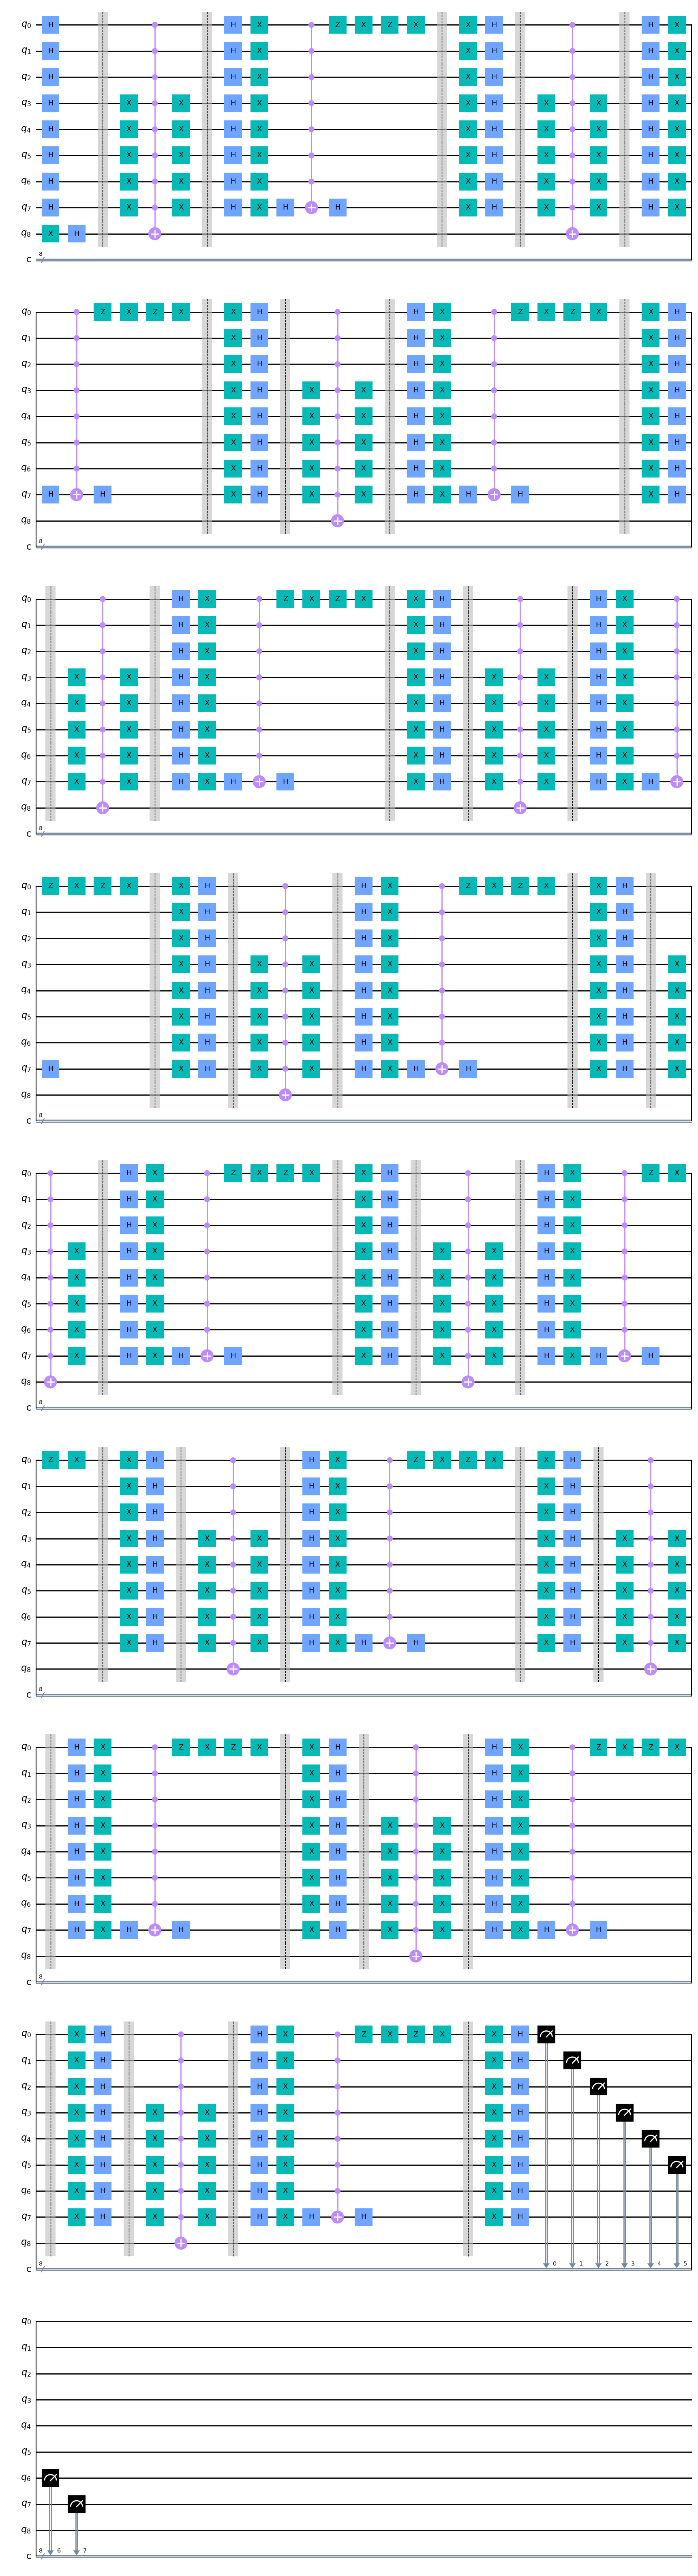

In [5]:
qc.draw(output="mpl",style="clifford")

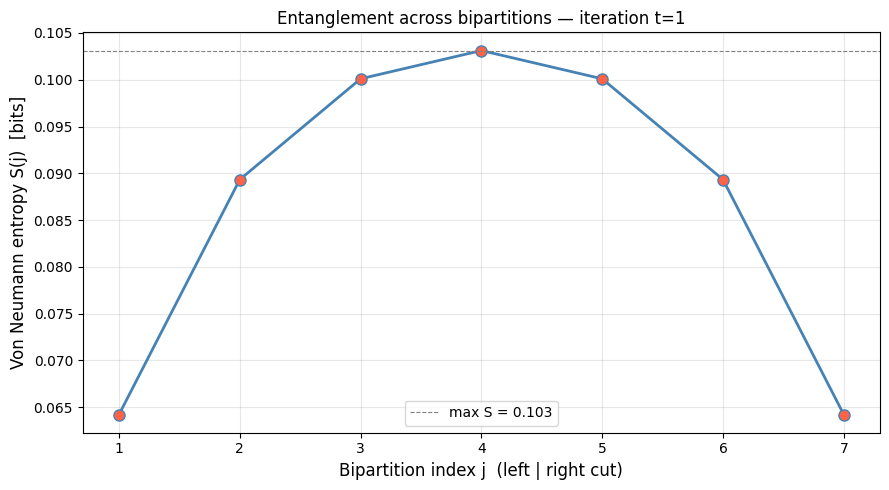

In [6]:
t_fixed = 1
qc = grover.construct_grover(qubits, k=t_fixed, marked_state=marked_state)
entropy.plot_entropy_vs_j(qc, n=qubits, t= t_fixed, extra_qubits=1)

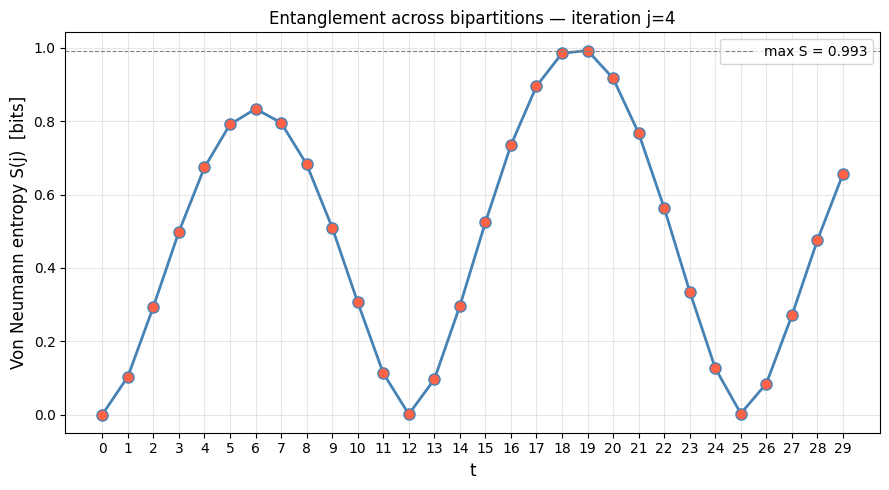

In [7]:
grover_lambda = lambda t: grover.construct_grover(qubits, t, marked_state=marked_state)
entropy.plot_entropy_vs_t(grover_lambda, n=qubits, j=qubits // 2, t_max=30, extra_qubits=1)

n= 2  j=1  S=0.00000
n= 3  j=1  S=0.19794
n= 4  j=2  S=0.90234
n= 5  j=2  S=0.00685
n= 6  j=3  S=0.51978
n= 7  j=3  S=0.76242
n= 8  j=4  S=0.67392
n= 9  j=4  S=0.48063
n=10  j=5  S=0.31261
n=11  j=5  S=0.19050
n=12  j=6  S=0.11236


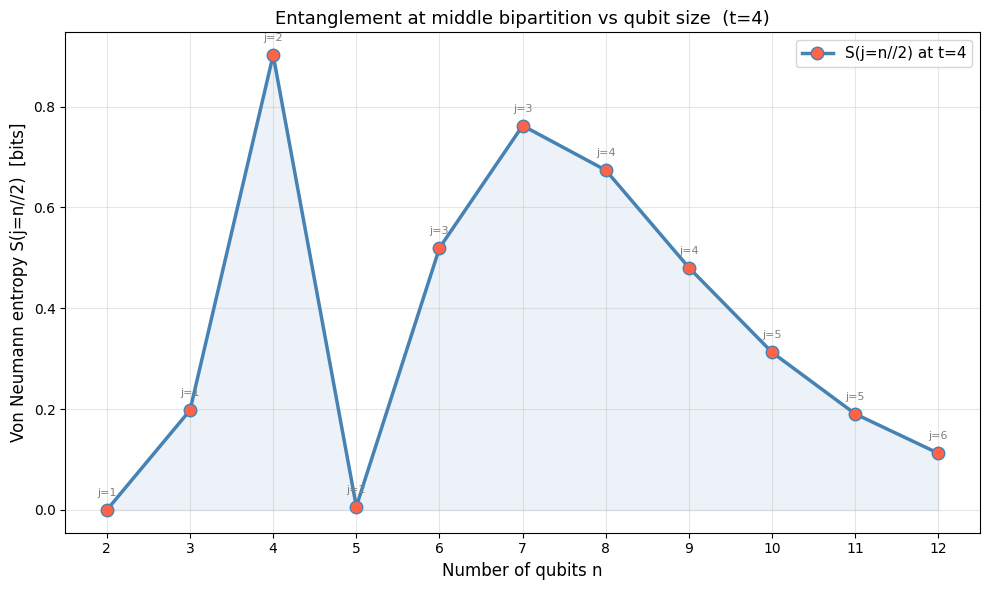

In [8]:
marked_state = 7
qubit_sizes  = list(range(2, 13))

# Single t
t_fixed  = 4
builder  = lambda n: grover.construct_grover(n, t_fixed, marked_state)
entropy.plot_entropy_vs_n(qubit_sizes, builder, t_fixed, extra_qubits=1)

n= 2  j=1  S=0.00000
n= 3  j=1  S=0.28344
n= 4  j=2  S=0.42502
n= 5  j=2  S=0.35592
n= 6  j=3  S=0.26031
n= 7  j=3  S=0.16689
n= 8  j=4  S=0.10312
n= 9  j=4  S=0.06042
n=10  j=5  S=0.03482
n=11  j=5  S=0.01954
n=12  j=6  S=0.01086
n= 2  j=1  S=0.00000
n= 3  j=1  S=0.92453
n= 4  j=2  S=0.17036
n= 5  j=2  S=0.32215
n= 6  j=3  S=0.69045
n= 7  j=3  S=0.65961
n= 8  j=4  S=0.49876
n= 9  j=4  S=0.32946
n=10  j=5  S=0.20520
n=11  j=5  S=0.12168
n=12  j=6  S=0.07045
n= 2  j=1  S=1.00000
n= 3  j=1  S=0.27825
n= 4  j=2  S=0.80715
n= 5  j=2  S=0.48488
n= 6  j=3  S=0.17773
n= 7  j=3  S=0.71476
n= 8  j=4  S=0.79118
n= 9  j=4  S=0.62029
n=10  j=5  S=0.42380
n=11  j=5  S=0.26588
n=12  j=6  S=0.15978
n= 2  j=1  S=0.00000
n= 3  j=1  S=0.15579
n= 4  j=2  S=0.78082
n= 5  j=2  S=0.41886
n= 6  j=3  S=0.88693
n= 7  j=3  S=0.36330
n= 8  j=4  S=0.30619
n= 9  j=4  S=0.83728
n=10  j=5  S=0.85696
n=11  j=5  S=0.65267
n=12  j=6  S=0.43737


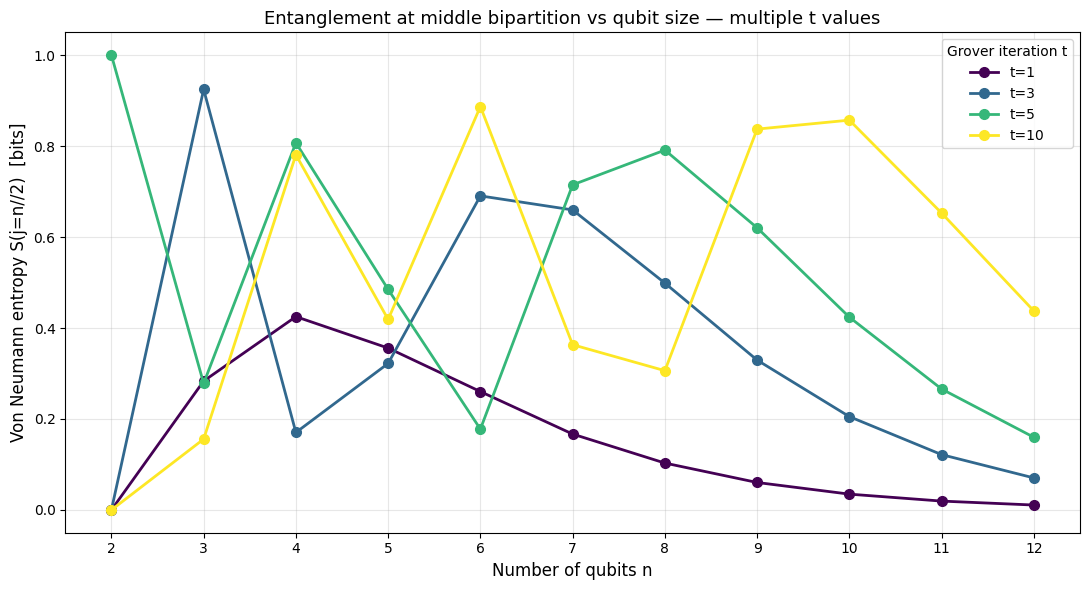

In [9]:
# Multiple t values — build one lambda per t
t_values      = [1, 3, 5, 10]
builder_per_t = [(t, lambda n, t=t: grover.construct_grover(n, t, marked_state))
                 for t in t_values]
entropy.plot_entropy_vs_n_multi_t(qubit_sizes, builder_per_t, extra_qubits=1)

# Grover algorithm MPS analysis

k= 1  sv=0.0327  mps=0.0362  theory=0.0348
k= 2  sv=0.0895  mps=0.0985  theory=0.0946
k= 3  sv=0.1907  mps=0.1826  theory=0.1797
k= 4  sv=0.2869  mps=0.2868  theory=0.2847
k= 5  sv=0.4079  mps=0.4033  theory=0.4032
k= 6  sv=0.5252  mps=0.5300  theory=0.5276
k= 7  sv=0.6498  mps=0.6517  theory=0.6503
k= 8  sv=0.7701  mps=0.7591  theory=0.7637
k= 9  sv=0.8589  mps=0.8631  theory=0.8607
k=10  sv=0.9379  mps=0.9354  theory=0.9352
k=11  sv=0.9819  mps=0.9840  theory=0.9826
k=12  sv=0.9999  mps=0.9998  theory=0.9999
k=13  sv=0.9881  mps=0.9854  theory=0.9862
k=14  sv=0.9455  mps=0.9442  theory=0.9422


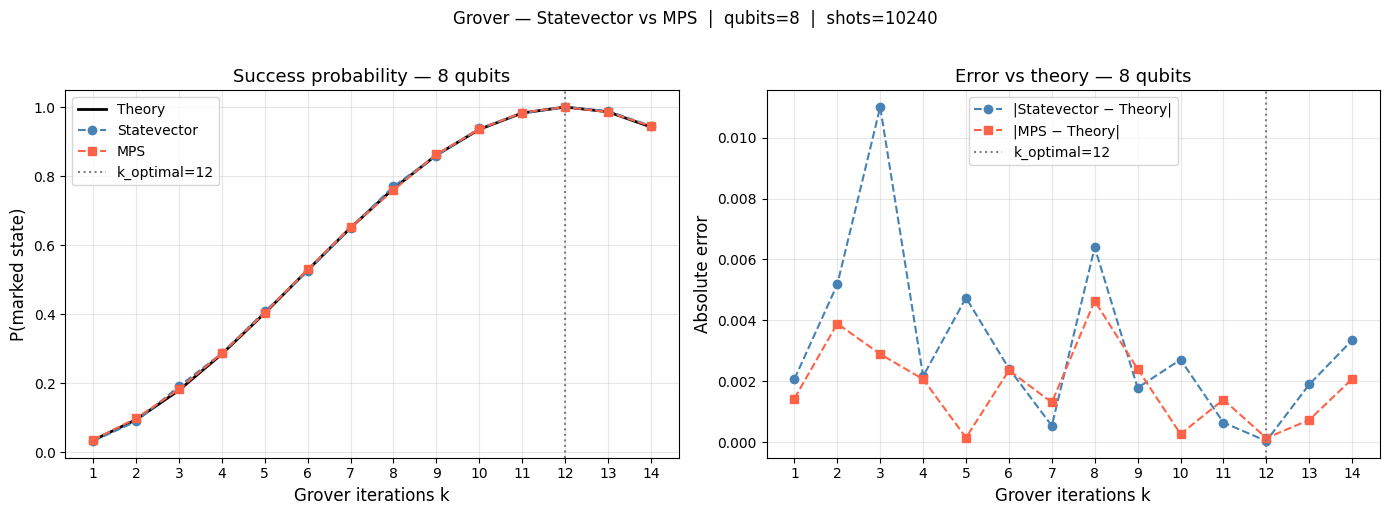

In [10]:
results = mps.run_comparison(
        circuit_builder  = lambda k: grover.construct_grover(qubits, k, marked_state),
        target_bitstring = lambda k: format(marked_state, f"0{qubits}b"),
        k_values         = range(1, k_optimal + 3),
        qubits           = qubits,
        shots            = shots,
        theory_fn        = lambda k: np.sin((2*k + 1) * theta)**2,
        k_optimal        = k_optimal,
        label_x          = "Grover iterations k",
        label_prob       = "P(marked state)",
        title            = "Grover — Statevector vs MPS",
    )

n= 4  sv=    0.023s  mps=0.165s
n= 5  sv=    0.024s  mps=0.189s
n= 6  sv=    0.057s  mps=0.338s
n= 7  sv=    0.054s  mps=0.189s
n= 8  sv=    0.065s  mps=0.185s
n= 9  sv=    0.101s  mps=0.288s
n=10  sv=    0.119s  mps=0.256s
n=11  sv=    0.255s  mps=0.418s
n=12  sv=    0.252s  mps=0.265s
n=13  sv=    0.553s  mps=0.252s
n=14  sv=    1.635s  mps=0.306s
n=15  sv=    9.844s  mps=0.502s
n=16  sv=   22.776s  mps=0.509s
n=17  sv=   21.675s  mps=0.966s
n=18  sv=   38.246s  mps=0.656s
n=19  sv=   61.188s  mps=1.442s


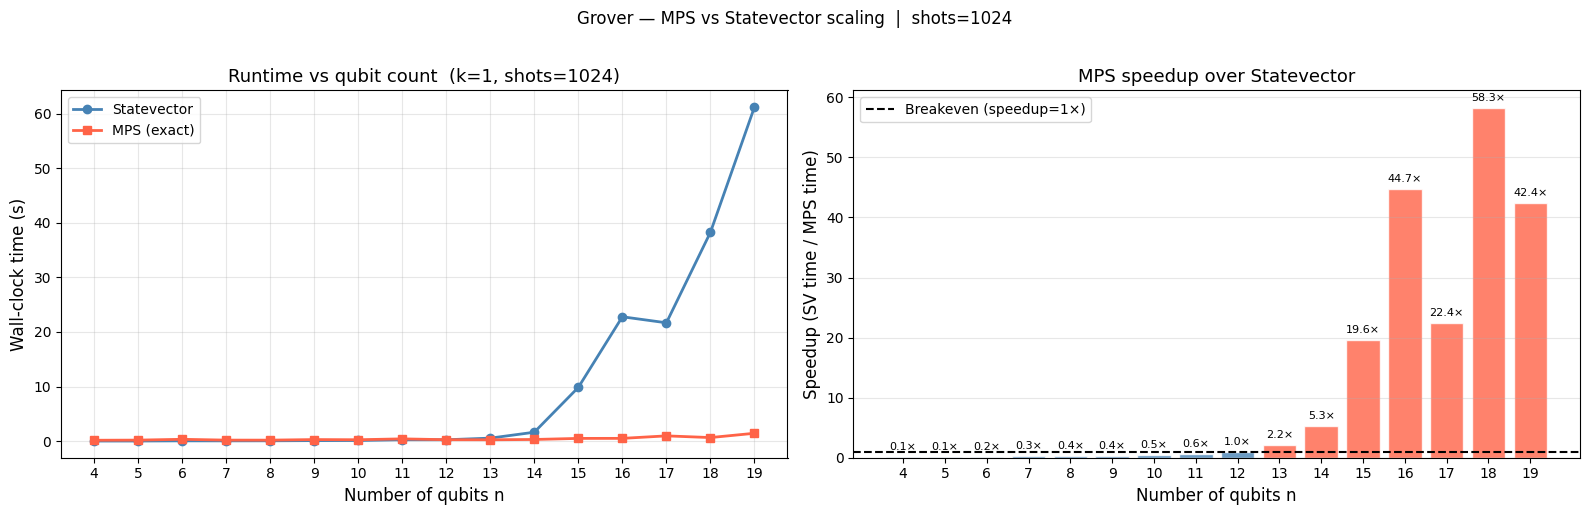

{'sv_times': [0.02306189799855929,
  0.02440301900060149,
  0.056784881999192294,
  0.05353614900013781,
  0.06528919799893629,
  0.10097296899766661,
  0.11946698300016578,
  0.2549118130009447,
  0.2521383249986684,
  0.552792752001551,
  1.634720459998789,
  9.844436505001795,
  22.776438404001965,
  21.67484649999824,
  38.24557096599892,
  61.18758903100024],
 'mps_times': [0.16507325500060688,
  0.1886869489972014,
  0.3375749370025005,
  0.18912566699873423,
  0.18499003399847425,
  0.28776096000001417,
  0.255797967001854,
  0.4179087270022137,
  0.2647056679998059,
  0.2524853470022208,
  0.30565593400024227,
  0.5017813249978644,
  0.5093757750000805,
  0.9662476570010767,
  0.6564711459977843,
  1.4416650089988252],
 'sv_failed': [False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False],
 'qubit_sizes': [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]}

In [12]:
shots       = 1024
k_fixed     = 1
qubit_sizes = list(range(4, 20))

mps.run_scaling_comparison(
    circuit_builder = lambda n: grover.construct_grover(
                            n, k_fixed,
                            0b10101010 & ((1 << n) - 1)   # marked state per n
                        ),
    qubit_sizes     = qubit_sizes,
    k_fixed         = k_fixed,
    shots           = shots,
    title           = "Grover — MPS vs Statevector scaling",
)

n= 4  sv=      0.52MB  mps=0.10MB
n= 5  sv=      0.62MB  mps=0.13MB
n= 6  sv=      0.73MB  mps=0.13MB
n= 7  sv=      0.85MB  mps=0.14MB
n= 8  sv=      0.99MB  mps=0.16MB
n= 9  sv=      1.32MB  mps=0.22MB
n=10  sv=      2.73MB  mps=0.26MB
n=11  sv=      5.77MB  mps=0.36MB
n=12  sv=     12.32MB  mps=0.39MB
n=13  sv=     26.43MB  mps=0.41MB
n=14  sv=     56.66MB  mps=0.41MB
n=15  sv=    121.29MB  mps=0.41MB
n=16  sv=    258.26MB  mps=0.42MB
n=17  sv=    548.54MB  mps=0.44MB
n=18  sv=   1161.61MB  mps=0.45MB
n=19  sv=   2453.04MB  mps=0.46MB


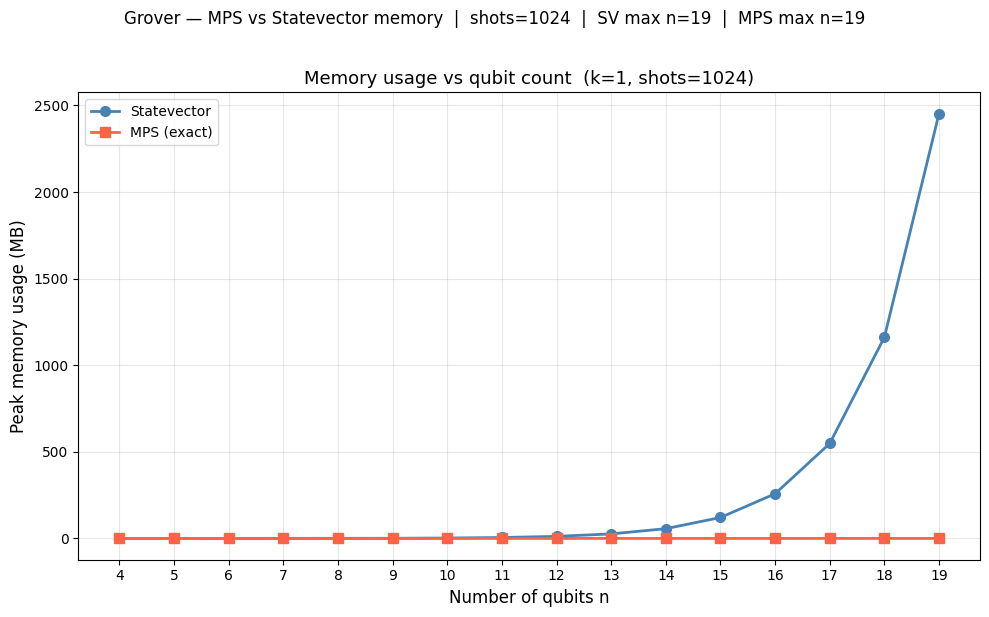

{'sv_memory': [0.5196723937988281,
  0.6171159744262695,
  0.7342720031738281,
  0.8546581268310547,
  0.9926357269287109,
  1.318572998046875,
  2.7312097549438477,
  5.766434669494629,
  12.317151069641113,
  26.431008338928223,
  56.65898609161377,
  121.28712558746338,
  258.25513553619385,
  548.5367136001587,
  1161.6059370040894,
  2453.0403146743774],
 'mps_memory': [0.1044921875,
  0.12891197204589844,
  0.13272953033447266,
  0.14453506469726562,
  0.15548133850097656,
  0.21607589721679688,
  0.25716495513916016,
  0.35851478576660156,
  0.3861560821533203,
  0.4079751968383789,
  0.41309356689453125,
  0.4088459014892578,
  0.41890907287597656,
  0.4427309036254883,
  0.45265674591064453,
  0.46134281158447266],
 'sv_failed': [False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False],
 'qubit_sizes': [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]}

In [13]:
mps.run_memory_comparison(
    circuit_builder = lambda n: grover.construct_grover(
                          n, k_fixed,
                          0b10101010 & ((1 << n) - 1)
                      ),
    qubit_sizes     = qubit_sizes,
    k_fixed         = k_fixed,
    shots           = shots,
    title           = "Grover — MPS vs Statevector memory",
)

# Quantum random walk entropy analysis

In [14]:
shots=1024
qubits = 7
t=50
shots = 1024

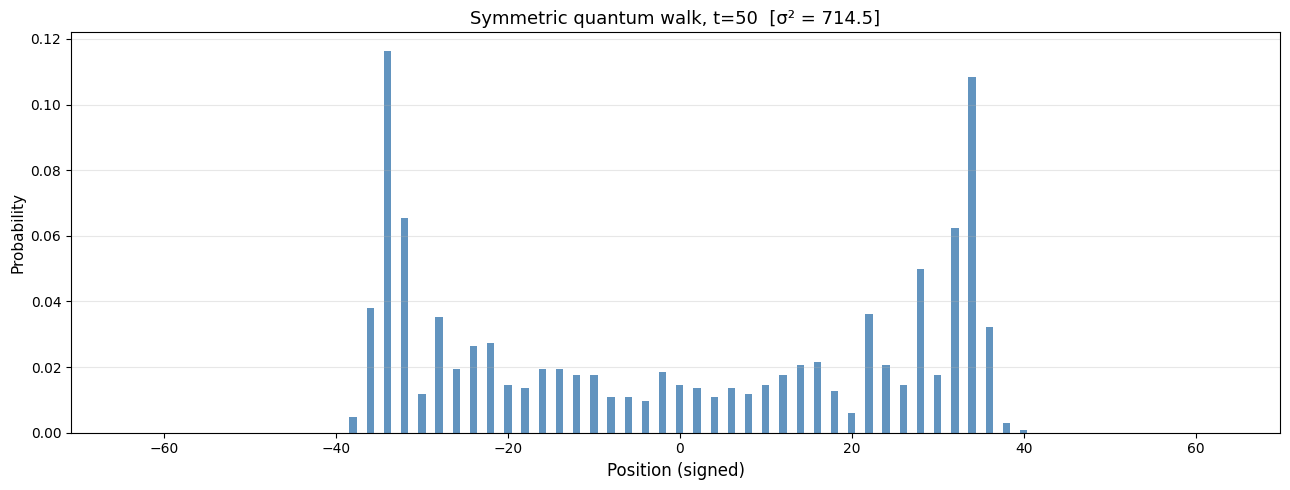

In [15]:
qrw.plot_walk(n_position_qubits=qubits, steps=t, shots = shots)

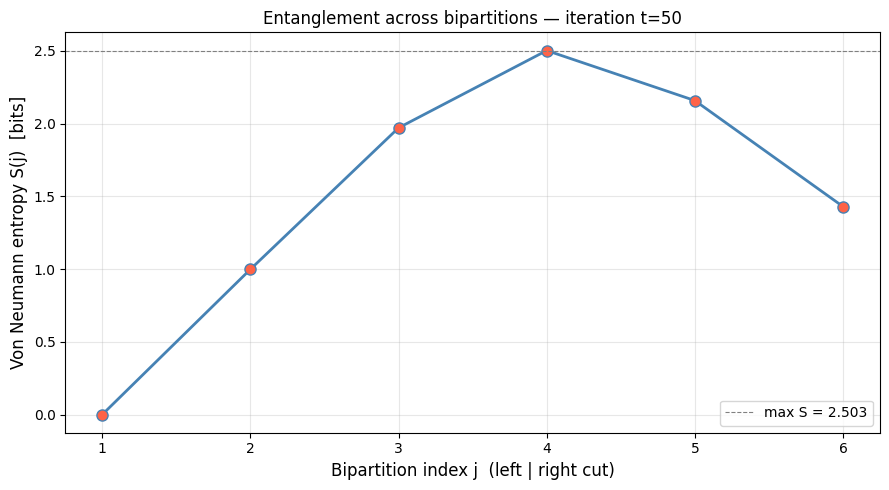

In [16]:
t_fixed = 50
qc = qrw.construct_walk(qubits, t_fixed)
entropy.plot_entropy_vs_j(qc, n=qubits, t= t_fixed, extra_qubits=1)

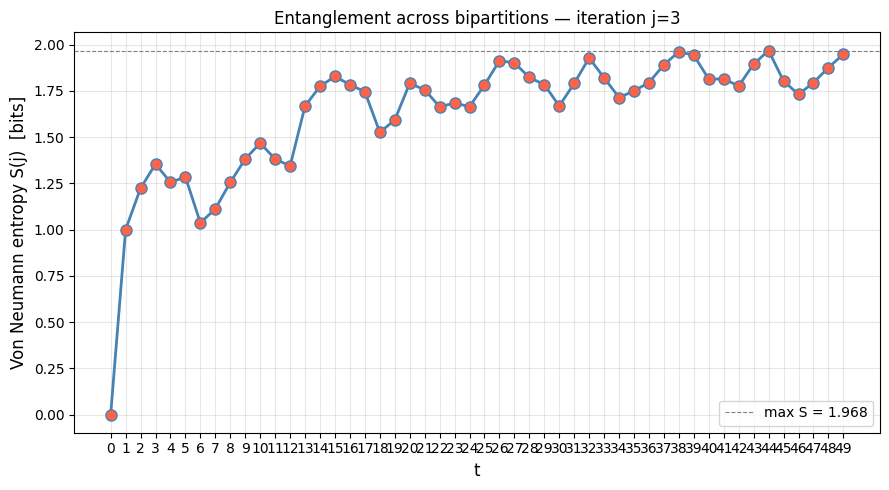

In [17]:
quantum_walk_lambda = lambda t: qrw.construct_walk(qubits, t)
entropy.plot_entropy_vs_t(quantum_walk_lambda, n=qubits, j=qubits // 2, t_max=50, extra_qubits=1)

n= 2  j=1  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=0.79885
n= 5  j=2  S=0.79885
n= 6  j=3  S=1.25553
n= 7  j=3  S=1.25553
n= 8  j=4  S=1.27998
n= 9  j=4  S=1.27998
n=10  j=5  S=1.27998
n=11  j=5  S=1.27998
n=12  j=6  S=1.27998


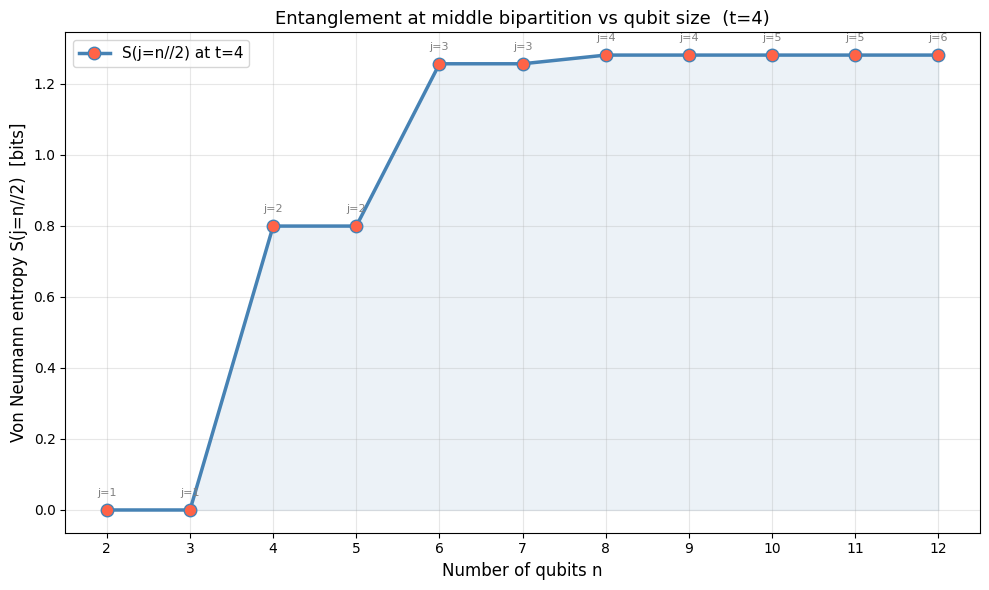

In [18]:
qubit_sizes  = list(range(2, 13))

t_fixed  = 4
builder  = lambda n: qrw.construct_walk(n, t_fixed)
entropy.plot_entropy_vs_n(qubit_sizes, builder, t_fixed, extra_qubits=1)

n= 2  j=1  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=1.00000
n= 5  j=2  S=1.00000
n= 6  j=3  S=1.00000
n= 7  j=3  S=1.00000
n= 8  j=4  S=1.00000
n= 9  j=4  S=1.00000
n=10  j=5  S=1.00000
n=11  j=5  S=1.00000
n=12  j=6  S=1.00000
n= 2  j=1  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=0.81128
n= 5  j=2  S=0.81128
n= 6  j=3  S=1.35458
n= 7  j=3  S=1.35458
n= 8  j=4  S=1.35458
n= 9  j=4  S=1.35458
n=10  j=5  S=1.35458
n=11  j=5  S=1.35458
n=12  j=6  S=1.35458
n= 2  j=1  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=0.98870
n= 5  j=2  S=0.98870
n= 6  j=3  S=1.28461
n= 7  j=3  S=1.28461
n= 8  j=4  S=1.43700
n= 9  j=4  S=1.43700
n=10  j=5  S=1.43700
n=11  j=5  S=1.43700
n=12  j=6  S=1.43700
n= 2  j=1  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=0.91282
n= 5  j=2  S=0.90476
n= 6  j=3  S=1.46779
n= 7  j=3  S=1.46779
n= 8  j=4  S=1.44592
n= 9  j=4  S=1.44592
n=10  j=5  S=1.48508
n=11  j=5  S=1.48508
n=12  j=6  S=1.48508
n= 2  j=1  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=0.94093
n= 5  j=2  S=

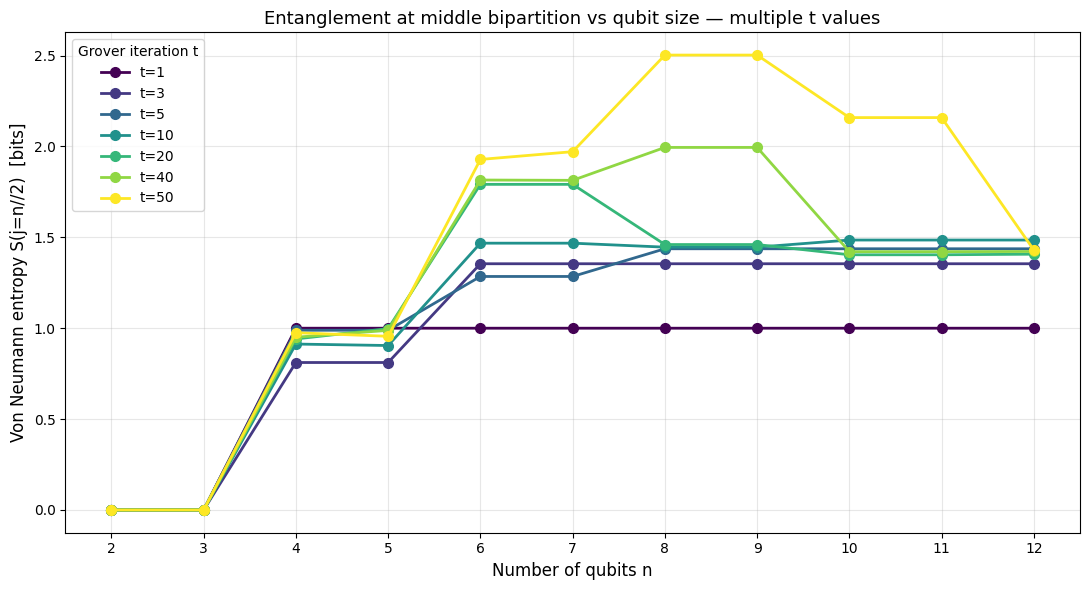

In [19]:
# Multiple t values — build one lambda per t
t_values      = [1, 3, 5, 10,20,40,50]
builder_per_t = [(t, lambda n, t=t: qrw.construct_walk(n, t))
                 for t in t_values]
entropy.plot_entropy_vs_n_multi_t(qubit_sizes, builder_per_t, extra_qubits=1)

# Quantum random walk MPS analysis

n= 4  sv=    0.069s  mps=0.084s
n= 5  sv=    0.037s  mps=0.083s
n= 6  sv=    0.088s  mps=0.121s
n= 7  sv=    0.167s  mps=0.172s
n= 8  sv=    0.245s  mps=0.206s
n= 9  sv=    0.432s  mps=0.329s
n=10  sv=    0.716s  mps=0.519s
n=11  sv=    1.239s  mps=0.670s
n=12  sv=    2.335s  mps=0.956s
n=13  sv=    6.737s  mps=1.158s
n=14  sv=   28.437s  mps=1.467s
n=15  sv=   57.313s  mps=1.970s
n=16  sv=  150.333s  mps=2.922s
n=17  sv=  287.044s  mps=2.965s


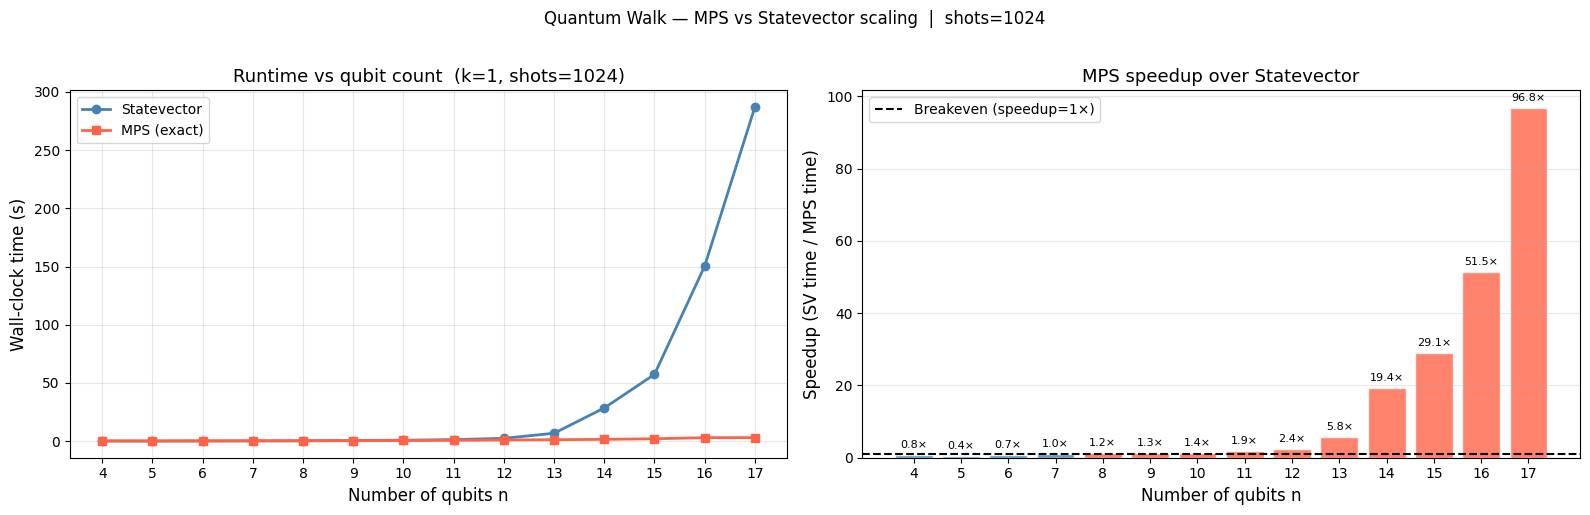

{'sv_times': [0.06903053700079909,
  0.03671323299931828,
  0.08803708000050392,
  0.16675501099962275,
  0.2450213430020085,
  0.4322558439998829,
  0.7158730500013917,
  1.2391930280027736,
  2.3347357179991377,
  6.7368258999995305,
  28.437269752001157,
  57.312818703998346,
  150.33270152200203,
  287.0441871820003],
 'mps_times': [0.08402148800087161,
  0.08341761399788084,
  0.12135405799926957,
  0.1719469929994375,
  0.20560859699980938,
  0.32878632199935964,
  0.5186771529988619,
  0.6697702289966401,
  0.9563469660024566,
  1.1579226440007915,
  1.467103989001771,
  1.970098539000901,
  2.9216474349996133,
  2.9647297080009594],
 'sv_failed': [False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False],
 'qubit_sizes': [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]}

In [20]:
shots       = 1024
k_fixed     = 1
qubit_sizes = list(range(4, 18))

mps.run_scaling_comparison(
    circuit_builder = lambda n: qrw.construct_walk_no_measure(n, k_fixed),
    qubit_sizes     = qubit_sizes,
    k_fixed         = k_fixed,
    shots           = shots,
    title           = "Quantum Walk — MPS vs Statevector scaling",
)

# Quantum Fourier transform entropy analysis

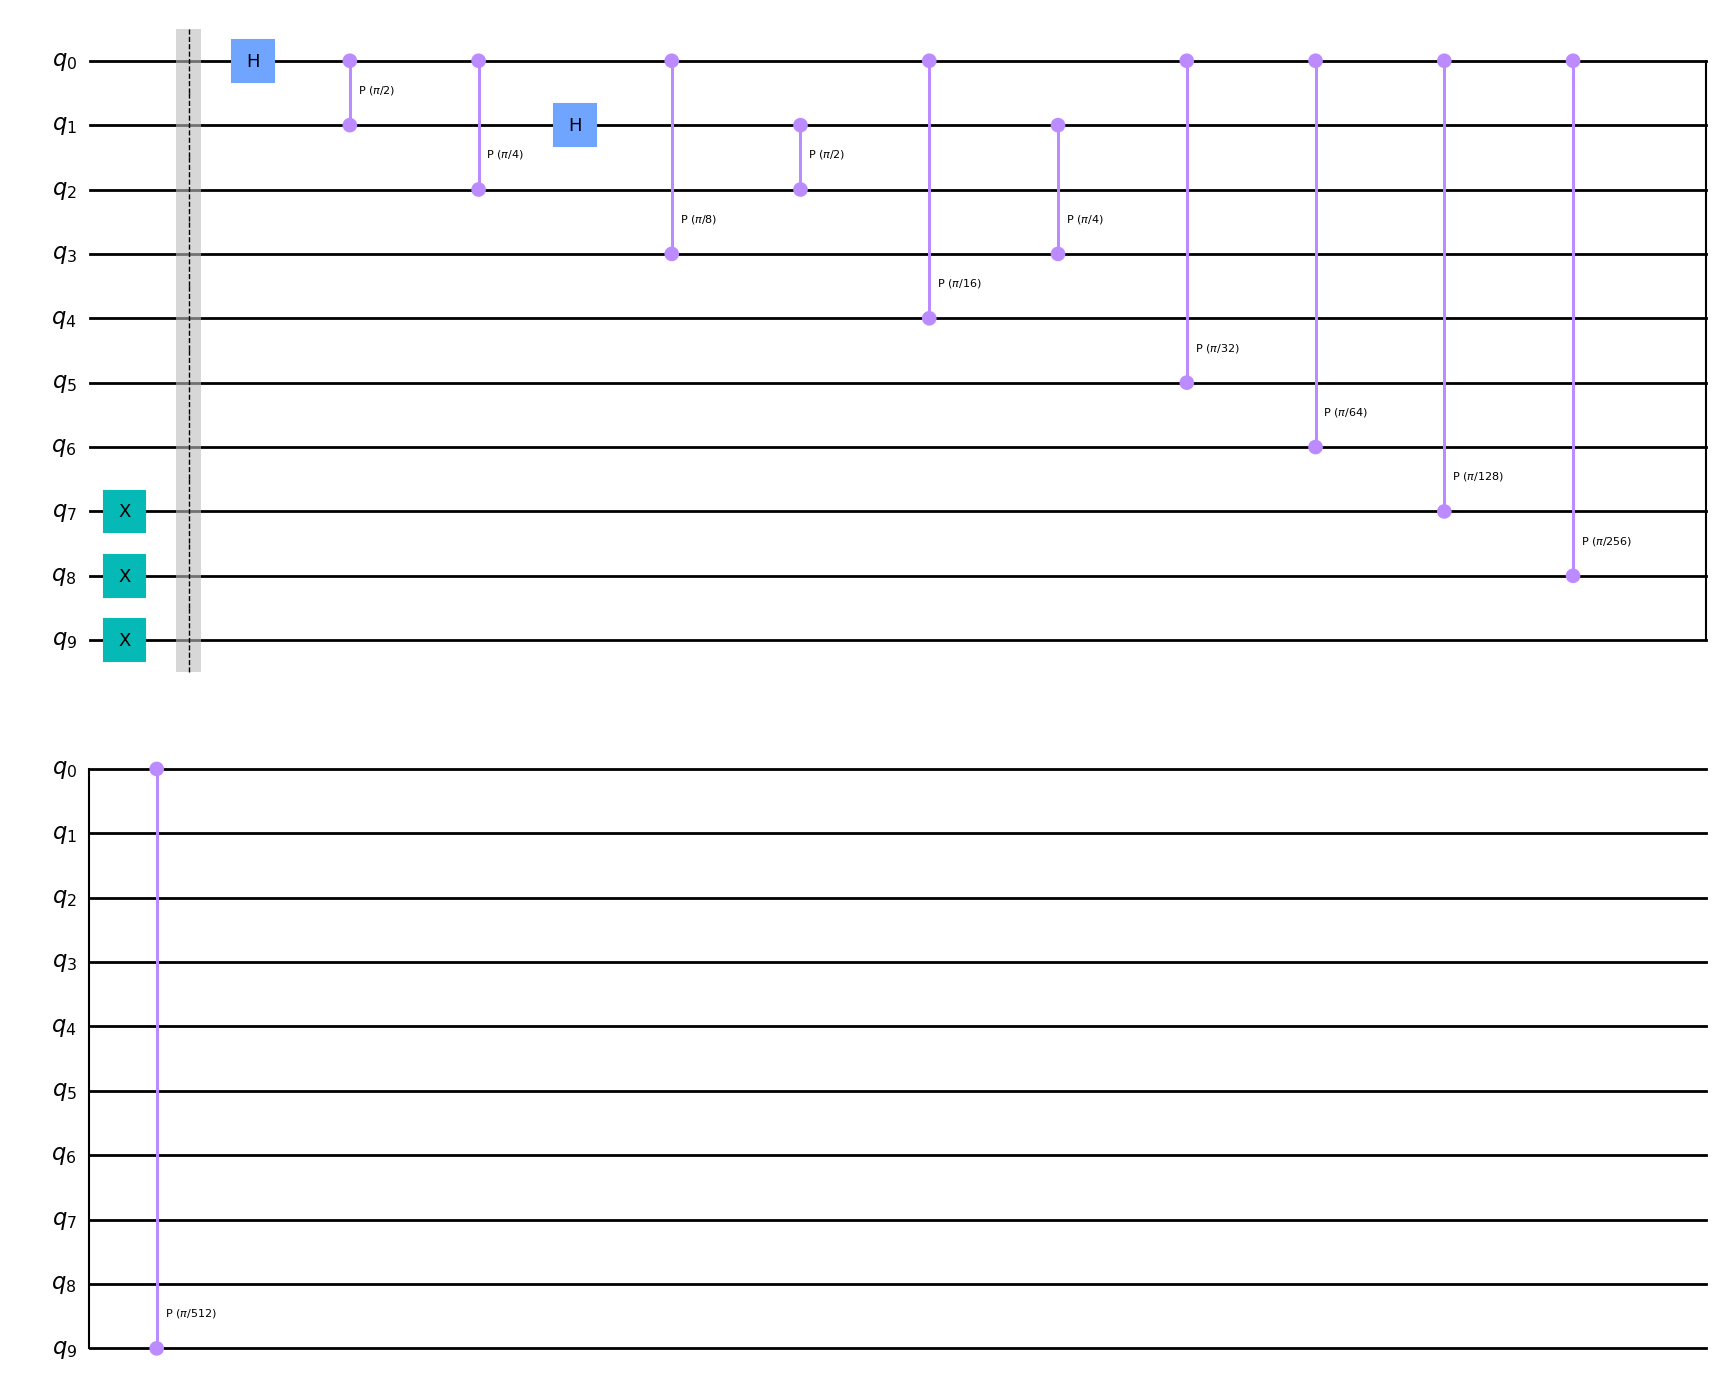

In [5]:
qubits = 10
t = 10
initial_state = 0b111

qc = qft.qft(qubits, t, initial_state)

qc.draw(output="mpl", style="clifford")

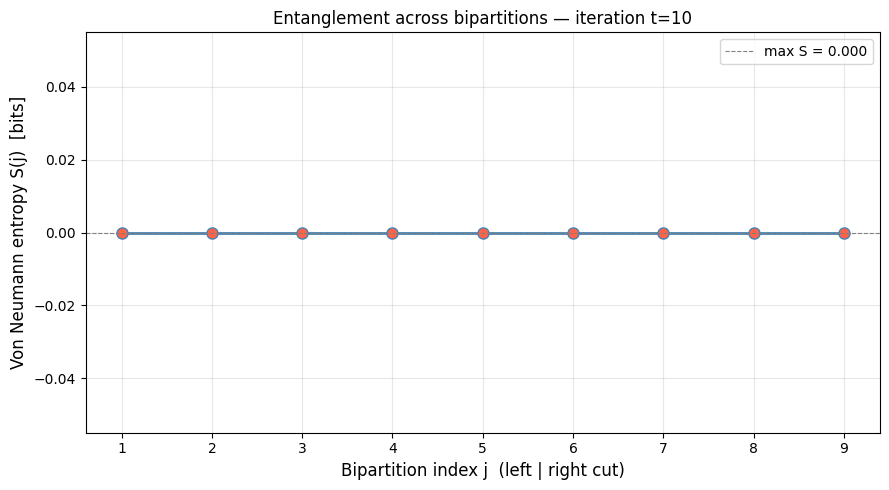

In [6]:
t_fixed = 10
qc = qft.qft(qubits, t=t_fixed, initial_state=initial_state)
entropy.plot_entropy_vs_j(qc, n=qubits, t= t_fixed, extra_qubits=0)

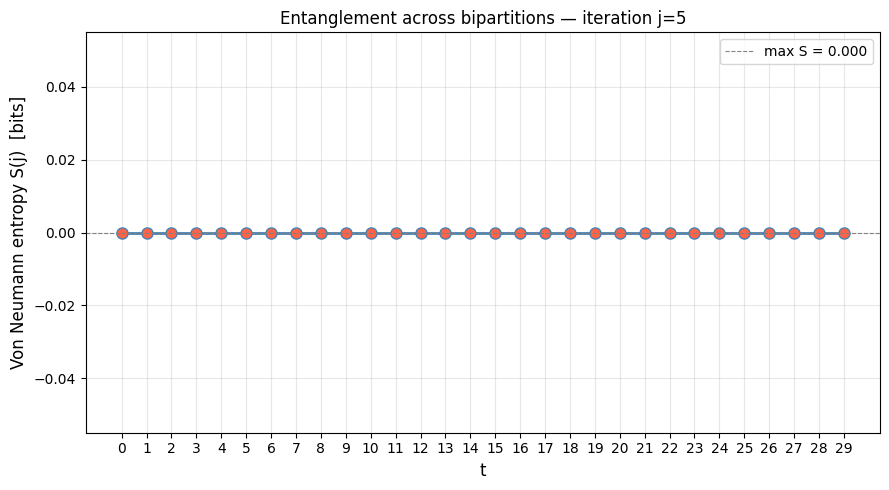

In [7]:
qft_lambda = lambda t: qft.qft(qubits, t, initial_state=initial_state)

entropy.plot_entropy_vs_t(qft_lambda, n=qubits, j=qubits // 2, t_max=30, extra_qubits=0)

n= 3  j=1  S=0.00000
n= 4  j=2  S=0.00000
n= 5  j=2  S=0.00000
n= 6  j=3  S=0.00000
n= 7  j=3  S=0.00000
n= 8  j=4  S=0.00000
n= 9  j=4  S=0.00000
n=10  j=5  S=0.00000
n=11  j=5  S=0.00000
n=12  j=6  S=0.00000


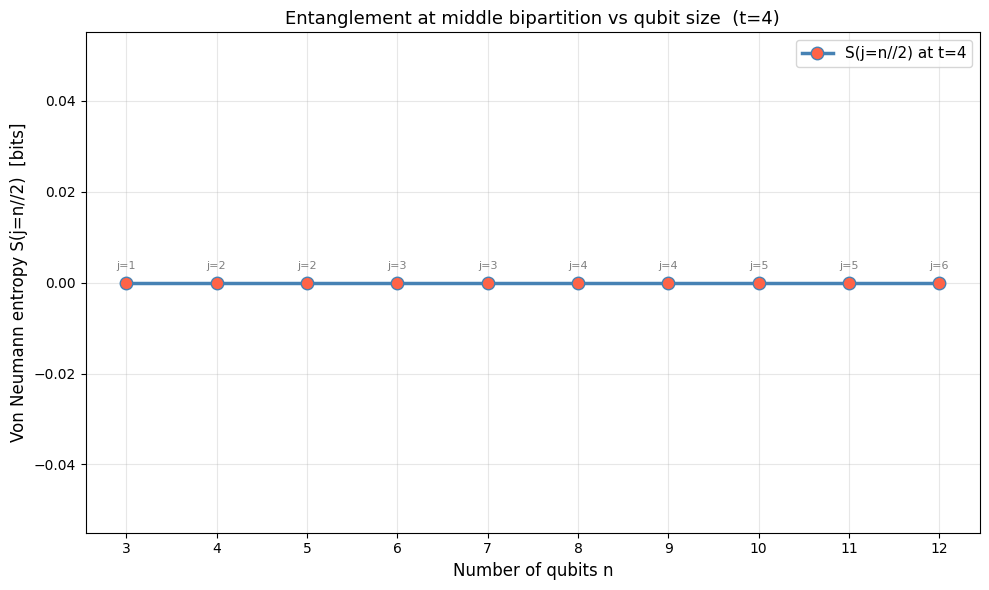

In [8]:
marked_state = 7
qubit_sizes  = list(range(3, 13))

# Single t
t_fixed  = 4
qft_lambda = lambda n: qft.qft(n, t_fixed, initial_state=initial_state)
entropy.plot_entropy_vs_n(qubit_sizes, qft_lambda, t_fixed, extra_qubits=0)

n= 3  j=1  S=0.00000
n= 4  j=2  S=0.00000
n= 5  j=2  S=0.00000
n= 6  j=3  S=0.00000
n= 7  j=3  S=0.00000
n= 8  j=4  S=0.00000
n= 9  j=4  S=0.00000
n=10  j=5  S=0.00000
n=11  j=5  S=0.00000
n=12  j=6  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=0.00000
n= 5  j=2  S=0.00000
n= 6  j=3  S=0.00000
n= 7  j=3  S=0.00000
n= 8  j=4  S=0.00000
n= 9  j=4  S=0.00000
n=10  j=5  S=0.00000
n=11  j=5  S=0.00000
n=12  j=6  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=0.00000
n= 5  j=2  S=0.00000
n= 6  j=3  S=0.00000
n= 7  j=3  S=0.00000
n= 8  j=4  S=0.00000
n= 9  j=4  S=0.00000
n=10  j=5  S=0.00000
n=11  j=5  S=0.00000
n=12  j=6  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=0.00000
n= 5  j=2  S=0.00000
n= 6  j=3  S=0.00000
n= 7  j=3  S=0.00000
n= 8  j=4  S=0.00000
n= 9  j=4  S=0.00000
n=10  j=5  S=0.00000
n=11  j=5  S=0.00000
n=12  j=6  S=0.00000


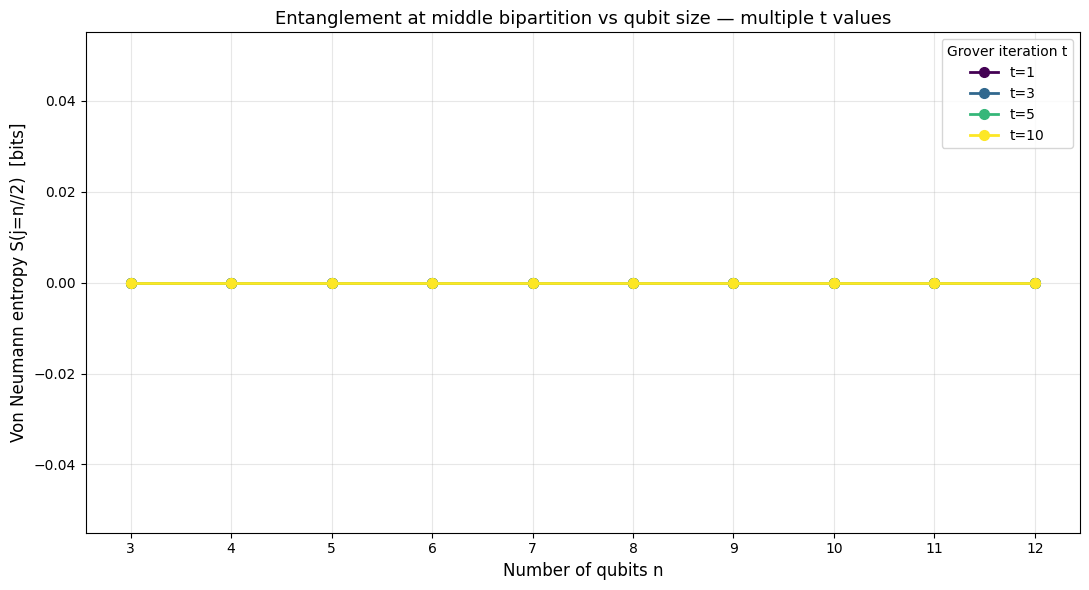

In [9]:
t_values      = [1, 3, 5, 10]

builder_per_t = [(t, lambda n, t=t: qft.qft(n, t, initial_state=initial_state))
                 for t in t_values]
entropy.plot_entropy_vs_n_multi_t(qubit_sizes, builder_per_t, extra_qubits=0)

# Quantum Fourier transform MPS analysis

k= 1  sv=0.0000  mps=0.0000
k= 2  sv=0.0000  mps=0.0000
k= 3  sv=0.0000  mps=0.0000
k= 4  sv=0.0000  mps=0.0000
k= 5  sv=0.0000  mps=0.0000
k= 6  sv=0.0000  mps=0.0000
k= 7  sv=0.0000  mps=0.0000


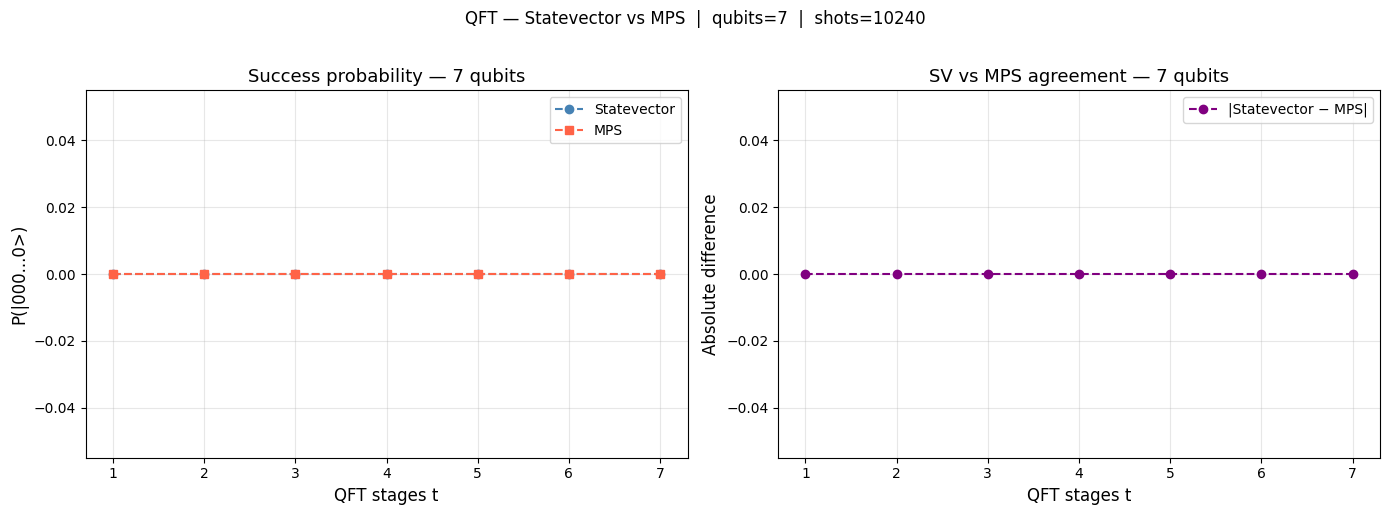

In [10]:
qubits     = 7
t_max = qubits
shots = 10240

results = mps.run_comparison(
    circuit_builder  = lambda t: qft.qft(qubits, t, initial_state),
    target_bitstring = lambda t: "0" * qubits,
    k_values         = range(1, t_max + 1),
    qubits           = qubits,
    shots            = shots,
    theory_fn        = None,
    k_optimal        = None,
    label_x          = "QFT stages t",
    label_prob       = "P(|000...0>)",
    title            = "QFT — Statevector vs MPS",
)

n= 4  sv=    0.006s  mps=0.047s
n= 5  sv=    0.005s  mps=0.114s
n= 6  sv=    0.005s  mps=0.041s
n= 7  sv=    0.010s  mps=0.045s
n= 8  sv=    0.007s  mps=0.051s
n= 9  sv=    0.006s  mps=0.046s
n=10  sv=    0.011s  mps=0.035s
n=11  sv=    0.013s  mps=0.061s
n=12  sv=    0.018s  mps=0.058s
n=13  sv=    0.032s  mps=0.051s
n=14  sv=    0.093s  mps=0.043s
n=15  sv=    0.220s  mps=0.048s
n=16  sv=    0.423s  mps=0.041s
n=17  sv=    0.838s  mps=0.052s
n=18  sv=    2.230s  mps=0.069s
n=19  sv=    4.765s  mps=0.094s


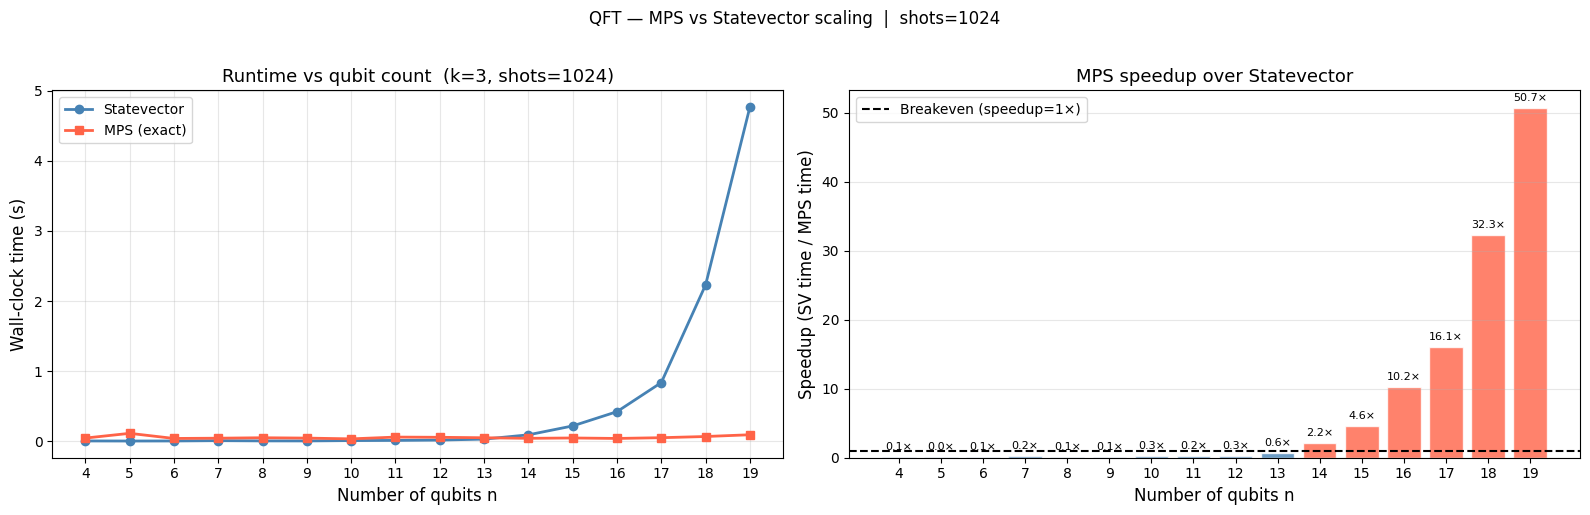

{'sv_times': [0.005812903999995456,
  0.004658446000007643,
  0.0054405650000006744,
  0.009877580000008379,
  0.00654152600000657,
  0.006027833000004534,
  0.010878152999993063,
  0.01331411400001059,
  0.018116994000010322,
  0.031703385999989564,
  0.0929274960000015,
  0.21982654900000398,
  0.4231507069999907,
  0.8375537750000035,
  2.2301954150000114,
  4.765283830000001],
 'mps_times': [0.046820369000002415,
  0.11413702700001238,
  0.04122844500000156,
  0.04491950699998881,
  0.051400233999999045,
  0.0464026549999943,
  0.03547362100000839,
  0.06070918900000777,
  0.05778834800000254,
  0.051116456000002586,
  0.04303514499999039,
  0.048044722000000206,
  0.04130790500001069,
  0.05208606899999779,
  0.06899692599999696,
  0.09397208100000398],
 'sv_failed': [False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False],
 'qubit_sizes': [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19

In [11]:
shots       = 1024
t_fixed     = 3       # fix number of QFT stages
qubit_sizes = list(range(4, 20))

mps.run_scaling_comparison(
    circuit_builder = lambda n: qft.qft(n, t_fixed, initial_state),
    qubit_sizes     = qubit_sizes,
    k_fixed         = t_fixed,
    shots           = shots,
    title           = "QFT — MPS vs Statevector scaling",
)

n= 4  sv=      0.14MB  mps=0.11MB
n= 5  sv=      0.16MB  mps=0.10MB
n= 6  sv=      0.18MB  mps=0.11MB
n= 7  sv=      0.24MB  mps=0.10MB
n= 8  sv=      0.51MB  mps=0.10MB
n= 9  sv=      1.14MB  mps=0.10MB
n=10  sv=      2.51MB  mps=0.10MB
n=11  sv=      5.50MB  mps=0.10MB
n=12  sv=     12.00MB  mps=0.11MB
n=13  sv=     26.02MB  mps=0.10MB
n=14  sv=     56.08MB  mps=0.11MB
n=15  sv=    120.27MB  mps=0.10MB
n=16  sv=    256.77MB  mps=0.11MB
n=17  sv=    546.02MB  mps=0.11MB
n=18  sv=   1157.02MB  mps=0.11MB
n=19  sv=   2444.02MB  mps=0.11MB


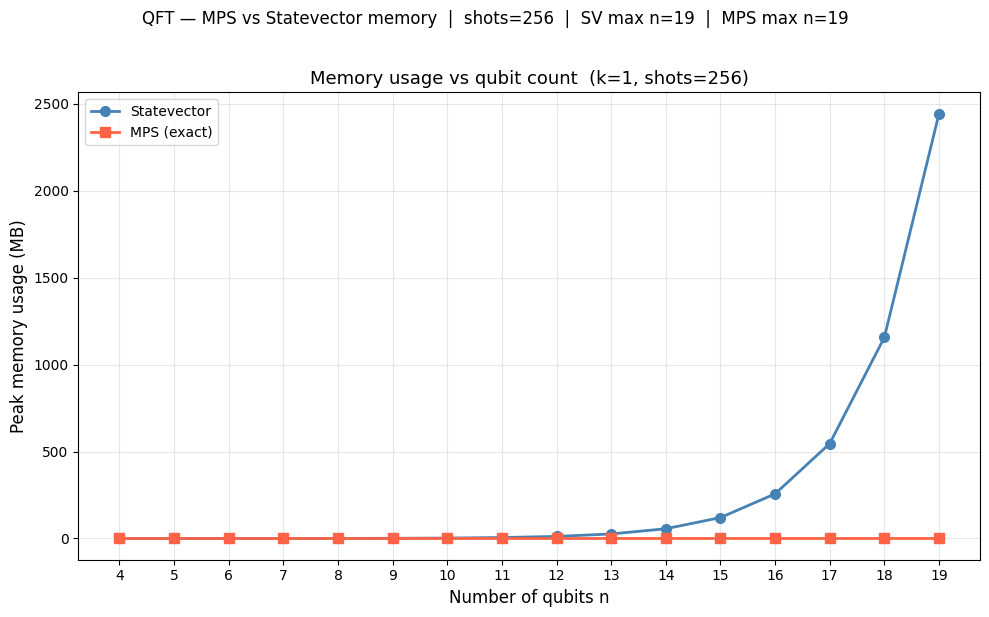

{'sv_memory': [0.13988780975341797,
  0.15920066833496094,
  0.18087005615234375,
  0.24180889129638672,
  0.5135164260864258,
  1.1363410949707031,
  2.5074357986450195,
  5.504855155944824,
  12.0048189163208,
  26.021077156066895,
  56.0845832824707,
  120.2718334197998,
  256.7725496292114,
  546.0239915847778,
  1157.024167060852,
  2444.024645805359],
 'mps_memory': [0.10738658905029297,
  0.10433483123779297,
  0.10527420043945312,
  0.10276508331298828,
  0.10423946380615234,
  0.10493850708007812,
  0.10471630096435547,
  0.10329341888427734,
  0.10560321807861328,
  0.10463142395019531,
  0.10567474365234375,
  0.10430526733398438,
  0.1051034927368164,
  0.10580730438232422,
  0.1056060791015625,
  0.10595989227294922],
 'sv_failed': [False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False],
 'qubit_sizes': [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]}

In [12]:
shots       = 256
k_fixed     = 1
qubit_sizes = list(range(4, 20))

mps.run_memory_comparison(
    circuit_builder = lambda n: qft.qft(n, k_fixed, initial_state),
    qubit_sizes     = qubit_sizes,
    k_fixed         = k_fixed,
    shots           = shots,
    title           = "QFT — MPS vs Statevector memory",
)